In [75]:
# installing dependencies and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [28]:
train = pd.read_csv('aps_failure_training_set.csv', skiprows = 20) #skiprows to account for header
test = pd.read_csv('aps_failure_test_set.csv', skiprows = 20)

In [54]:
# train.head()
test.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [30]:
# Shape of train and test sets
print(f"Training set: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test set:     {test.shape[0]} rows, {test.shape[1]} columns")

Training set: 60000 rows, 171 columns
Test set:     16000 rows, 171 columns


In [31]:
print("All columns: ", train.columns.tolist())

All columns:  ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000', 'cl_000'

In [32]:
print("Training set class distribution:")
print(train['class'].value_counts())

print("Test set class distribution:")
print(test['class'].value_counts())

Training set class distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64
Test set class distribution:
class
neg    15625
pos      375
Name: count, dtype: int64


### Data Cleaning

In [35]:
y = train['class'].map({'neg':0, 'pos':1}) # encoding (Negative Class = 0, Posotive class = 1)

In [34]:
X = train.drop('class', axis=1).replace('na', np.nan).apply(pd.to_numeric, errors='coerce') # drop target 'class' and treat NA values
test_X = test.drop('class', axis=1).replace('na', np.nan).apply(pd.to_numeric, errors='coerce') # sam strategy for test_X

In [36]:
# Dropping columns with >50% missing. This could help reduce the parameters as well
miss_mean = X.isna().mean()
to_drop = miss_mean[miss_mean > 0.5].index
print(f"Dropping {len(to_drop)} columns with >50% missing")

X = X.drop(columns=to_drop)
test_X = test.drop(columns=to_drop+['class'], errors='ignore')

Dropping 8 columns with >50% missing


In [37]:
test_X = test_X[X.columns]

In [38]:
# Since 8 columns with more than 50 % missing, we instead replace NA values with the median of the row for the remaining.
# This choice is due to the fact that some columns have a huge range of values (outliers) which might throw the average off
# We can use Simple Imputer for this:

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
test_imp = pd.DataFrame(imputer.transform(test_X), columns=X.columns, index=test_X.index)

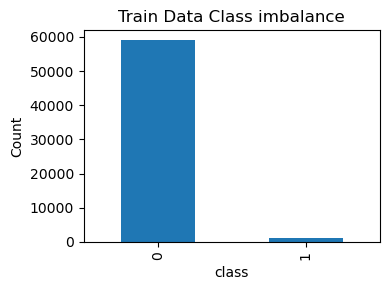

In [41]:
# Data viz for understanding the dataset
plt.figure(figsize=(4,3))
y.value_counts().plot.bar()
plt.title("Train Data Class imbalance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Logistic Regression

The easiest Baseline would be to just predict Neg=0 for all data points. This is because there are 59000 Neg points and only 1000 Pos points. This gives us an accuracy of ~ 98% . However, our costs for FN = 500. So, total cost for Test set would be 500* 375. Hence, accuracy is not an important metric here, Cost is. So, we will be trying to minimize cost.

In [43]:
# We can utilize Logistic Regression here to minimize our Total Cost. Since the dataset implies that this is a Classification problem,
# Log Reg would be a perfect baseline, if not target model

# First, we define our costs helper function :
# We know that False positive in this case has a Cost of 10 while a False Negative has a Cost of 500
def cost_metric(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1]) # building confusion matrix
    tn, fp, fn, tp = cm.ravel()
    return 10*fp + 500*fn # return total cost according to the losses

cost_scorer = make_scorer(cost_metric, greater_is_better=False)

In [45]:
lr = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, class_weight={0:10, 1:500}) # using l2 regularization

In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5 fold CV 
scores = cross_val_score(lr, X_imp, y, cv=cv, scoring=cost_scorer)
print("LogReg CV cost (per fold):", scores)
print("Mean cost:", np.mean(scores))

E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg CV cost (per fold): [-11080 -12820 -12490 -14470 -10710]
Mean cost: -12314.0


E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [47]:
# to make the costs positive (the scorer always tries to maximize the score and hence gives the flipped sign)
raw_costs = -scores
print("Raw costs per fold:", raw_costs)
print("Average raw cost:  ", raw_costs.mean())

Raw costs per fold: [11080 12820 12490 14470 10710]
Average raw cost:   12314.0


In [81]:
# For threshold sweeping, we take a small sample in hold variables 
X_train, X_hold, y_train, y_hold = train_test_split( X_imp, y, test_size=0.2, stratify=y, random_state=42)

In [79]:
# Grid Search for Log Reg
lr = LogisticRegression(solver='saga', max_iter=2000)
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'class_weight': [{0:10,1:500}] }

gs_lr = GridSearchCV(lr, param_grid_lr,scoring=cost_scorer,cv=cv,n_jobs=-1,verbose=1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)
print("LR best CV cost:", gs_lr.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params: {'C': 10, 'class_weight': {0: 10, 1: 500}}
LR best CV cost: -10380.0


E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [82]:
# Threshold sweep on hold-out for the best Log reg model
best_model = gs_lr.best_estimator_
probs = best_model.predict_proba(X_hold)[:,1]

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_hold, preds, labels=[0,1]).ravel()
    costs.append(10*fp + 500*fn)

best_idx = np.argmin(costs)
print(f"Optimal threshold: {thresholds[best_idx]:.2f}, Cost: {costs[best_idx]}")

Optimal threshold: 0.32, Cost: 9660


These are according to the best tuned Log Reg Model. We have a threshold probability of 0.32 and total cost 9660. However, this is just for 20% of our training set that we used as Validation. 

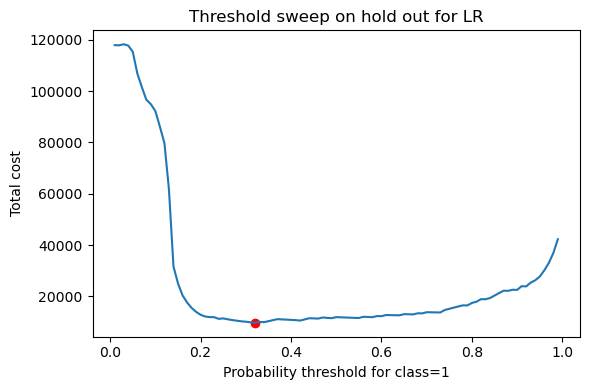

In [84]:
# Cost vs threshold for LR
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs)
plt.scatter(thresholds[best_idx], costs[best_idx], color='red')
plt.xlabel("Probability threshold for class=1")
plt.ylabel("Total cost")
plt.title("Threshold sweep on hold out for LR")
plt.tight_layout()
plt.show()

### Random Forest

In [51]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight={0:10, 1:500}, random_state=42, n_jobs=-1)
scores_rf = cross_val_score(rf, X_imp, y, cv=cv, scoring=cost_scorer)
print("RF   CV cost (per fold):", scores_rf)
print("Mean cost:", np.mean(scores_rf))

RF   CV cost (per fold): [-13210 -16050 -13210 -19750 -15530]
Mean cost: -15550.0


In [53]:
raw_costs = -scores_rf
print("Raw costs per fold:", raw_costs)
print("Average raw cost:  ", raw_costs.mean())

Raw costs per fold: [13210 16050 13210 19750 15530]
Average raw cost:   15550.0


In [63]:
# Grid Serach CV For Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = { 'n_estimators': [100, 300], 'max_depth': [ 10, 20],'class_weight': [{0:10,1:500}]}

gs_rf = GridSearchCV( rf, param_grid_rf, scoring=cost_scorer, cv=cv, n_jobs=-1,verbose=1)
gs_rf.fit(X_imp, y)
print("Best RF params:", gs_rf.best_params_)
print("RF  best CV cost:", gs_rf.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF params: {'class_weight': {0: 10, 1: 500}, 'max_depth': 10, 'n_estimators': 100}
RF  best CV cost: -15378.0


In [66]:
# Threshold sweep for RF
best_model = gs_rf.best_estimator_
probs = best_model.predict_proba(X_hold)[:,1]
costs = []

for t in thresholds: 
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_hold, preds, labels=[0,1]).ravel()
    costs.append(10*fp + 500*fn)

best_idx = np.argmin(costs)
print(f"Optimal threshold: {thresholds[best_idx]:.2f}, Cost: {costs[best_idx]}")

Optimal threshold: 0.46, Cost: 2890


This is just for 20 % of our training set. We haven't applied it to the test set yet. 
Our probability threshold is 0.46

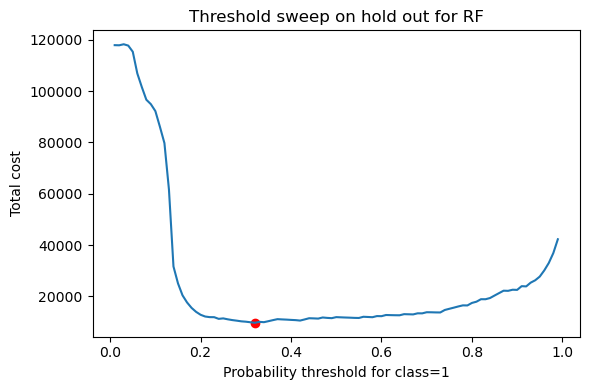

In [85]:
# Cost vs. threshold for RF
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs)
plt.scatter(thresholds[best_idx], costs[best_idx], color='red')
plt.xlabel("Probability threshold for class=1")
plt.ylabel("Total cost")
plt.title("Threshold sweep on hold out for RF")
plt.tight_layout()
plt.show()

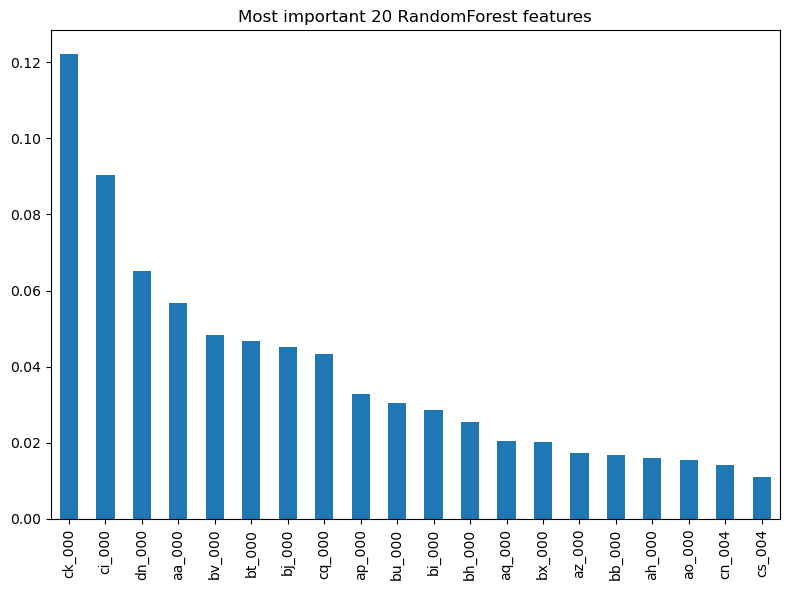

In [70]:
# Feature importances (RF)
importances = pd.Series( best_model.feature_importances_, index=X_imp.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
importances.plot.bar()
plt.title("Most important 20 RandomForest features")
plt.tight_layout()
plt.show()

### Applying to Test set

In [87]:
# Prepare X and y for testing exactly as before.
y_test = test['class'].map({'neg':0,'pos':1}).values
X_test = (test.drop('class',axis=1).replace('na', np.nan).apply(pd.to_numeric, errors='coerce'))

X_test = X_test[X_imp.columns]  # same order
X_test_imp = pd.DataFrame(imputer.transform(X_test),columns=X_imp.columns)

In [76]:
# Predict with our best model (the tuned RF):
probs_test = best_model.predict_proba(X_test_imp)[:,1]
preds_test = (probs_test >= 0.46).astype(int) # Note that we use our optimal probability here

# Confusion matrix and cost:
tn, fp, fn, tp = confusion_matrix(y_test, preds_test, labels=[0,1]).ravel()
total_cost_test = 10*fp + 500*fn
accuracy_test = accuracy_score(y_test, preds_test)

print("Test Confusion Matrix:")
print(f" TN={tn}  FP={fp}")
print(f" FN={fn}  TP={tp}")

print(f"Test Cost = {total_cost_test}")
print(f"Test Accuracy = {accuracy_test:.4f}")

Test Confusion Matrix:
 TN=15319  FP=306
 FN=33  TP=342

Test Cost     = 19560
Test Accuracy = 0.9788


In [88]:
# Predict with our best model (the tuned LR)
best_model = gs_lr.best_estimator_
probs_test = best_model.predict_proba(X_test_imp)[:,1]
preds_test = (probs_test >= 0.46).astype(int) # Note that we use our optimal probability here

# Confusion matrix and cost:
tn, fp, fn, tp = confusion_matrix(y_test, preds_test, labels=[0,1]).ravel()
total_cost_test = 10*fp + 500*fn
accuracy_test   = accuracy_score(y_test, preds_test)

print("Test Confusion Matrix:")
print(f" TN={tn}  FP={fp}")
print(f" FN={fn}  TP={tp}")

print(f"Test Cost = {total_cost_test}")
print(f"Test Accuracy = {accuracy_test:.4f}")

Test Confusion Matrix:
 TN=15161  FP=464
 FN=28  TP=347
Test Cost     = 18640
Test Accuracy = 0.9692


### Model Results

We extensively used Logistic Regression and Random Forest, tuned them using Cross-validation and minimized costs (maximized cost score) to get the best model. These results are not on the Test Set! 

| Model | Cost |
|------- | ----------| 
| Baseline  | 59000 |
|  Logistic Regression (w/o GridSearch)     | 12314     |
|Logistic Regression (with GridSearch) | 10380  |
| Random Forest (w/o GridSearch) | 15550 |
|Randome Forest (with GridSearch)  | 15378 |


On the Test set, we applied the tuned Log Reg and RF models to get:

| Model | Cost | Accuracy | 
|------- | ----------| -----| 
| Logistic Regression  | 18640 | 0.9692 | 
|  Random Forest    |19560    | 0.9788 |

### Improvement using Histogram bins

The idea here is to group the histograms and then use their summary features like Mean, Variance, Entropy in our models.
This improves the training as:
1) It reduces Dimensionality
2) Record continuous behavior

In [89]:
import re
from collections import defaultdict

# X_imp is our imputed train DataFrame
hist_groups = defaultdict(list)
for col in X_imp.columns:
    m = re.match(r"(.+)_Bin(\d+)$", col)
    if m:
        var, b = m.groups()
        hist_groups[var].append((int(b), col))

# sort bins
for var in hist_groups:
    hist_groups[var] = [c for _,c in sorted(hist_groups[var])]

In [92]:
#  midpoints for each variable
midpoints = {'T': [-30, -10, 10, 30],'P': [...], }

summaries = {}
for var, cols in hist_groups.items():
    mids = np.array(midpoints[var])
    data = X_imp[cols].values
    total = data.sum(axis=1).reshape(-1,1)
    total[total == 0] = 1  # to prevent error 
    
    # finding the metrics
    mean  = (data * mids).sum(axis=1) / total.flatten()
    var   = ((data * (mids**2)).sum(axis=1) / total.flatten()) - mean**2
    probs = data / total
    entropy = -np.nansum(probs * np.log(probs + 1e-9), axis=1)
    extreme_frac = (data[:,0] + data[:,-1]) / total.flatten()
    
    summaries[f"{var}_mean"] = mean
    summaries[f"{var}_var"]  = var
    summaries[f"{var}_entropy"] = entropy
    summaries[f"{var}_extreme_frac"] = extreme_frac

# build dataframe of new features
df_hist = pd.DataFrame(summaries, index=X_imp.index)

X_feat = pd.concat([X_imp.drop(columns=sum(hist_groups.values(), [])), df_hist], axis=1)

( From here on, we will be re-using the code from before by just changing our X_imp dataset to X_feat)

In [93]:
lr = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, class_weight={0:10, 1:500}) # using l2 regularization
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5 fold CV 
scores = cross_val_score(lr, X_feat, y, cv=cv, scoring=cost_scorer)
print("LogReg CV cost (per fold):", scores)
print("Mean cost:", np.mean(scores))

E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg CV cost (per fold): [-11140 -12820 -12060 -13560 -11780]
Mean cost: -12272.0


E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [94]:
# to make the costs positive (the scorer always tries to maximize the score and hence gives the flipped sign)
raw_costs = -scores
print("Raw costs per fold:", raw_costs)
print("Average raw cost:  ", raw_costs.mean())

Raw costs per fold: [11140 12820 12060 13560 11780]
Average raw cost:   12272.0


In [95]:
X_train, X_hold, y_train, y_hold = train_test_split( X_feat, y, test_size=0.2, stratify=y, random_state=42)

In [96]:
# Grid Search for Log Reg
lr = LogisticRegression(solver='saga', max_iter=2000)
param_grid_lr = {'C': [0.01, 0.1, 1, 10],'class_weight': [{0:10,1:500}]}

gs_lr = GridSearchCV(lr, param_grid_lr,scoring=cost_scorer,cv=cv,n_jobs=-1,verbose=1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)
print("LR best CV cost:", gs_lr.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params: {'C': 0.01, 'class_weight': {0: 10, 1: 500}}
LR best CV cost: -10120.0


E:\CONDA\envs\PY\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [97]:
# Threshold sweep on hold-out for the best Log reg model
best_model = gs_lr.best_estimator_
probs = best_model.predict_proba(X_hold)[:,1]

costs = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_hold, preds, labels=[0,1]).ravel()
    costs.append(10*fp + 500*fn)

best_idx = np.argmin(costs)
print(f"Optimal threshold: {thresholds[best_idx]:.2f}, Cost: {costs[best_idx]}")

Optimal threshold: 0.32, Cost: 9680


In [98]:
# Predict with our best model (the tuned LR + histogram augmentation)
best_model = gs_lr.best_estimator_
probs_test = best_model.predict_proba(X_test_imp)[:,1]
preds_test = (probs_test >= 0.46).astype(int) # Note that we use our optimal probability here

# Confusion matrix and cost:
tn, fp, fn, tp = confusion_matrix(y_test, preds_test, labels=[0,1]).ravel()
total_cost_test = 10*fp + 500*fn
accuracy_test   = accuracy_score(y_test, preds_test)

print("Test Confusion Matrix:")
print(f" TN={tn}  FP={fp}")
print(f" FN={fn}  TP={tp}")

print(f"Test Cost     = {total_cost_test}")
print(f"Test Accuracy = {accuracy_test:.4f}")

Test Confusion Matrix:
 TN=15165  FP=460
 FN=28  TP=347
Test Cost     = 18600
Test Accuracy = 0.9695


Finally, we get the following results after Histogram augmentation in our data:

| Model | Cost | Accuracy | 
|------- | ----------| -----| 
| Logistic Regression  | 18640 | 0.9692 | 
|  Random Forest    |19560    | 0.9788 |
| Logistic Regresssion (with Histogram Augmentation) | 18600 | 0.9695 |

Hence, we note that the minimium cost we obtain is $\mathbf{18600}$ for Logistic Regression Model with suggested Improvements like Histogram Augmentation. The accuracy is also not bad with 0.9695 but as mentioned before our main metric in the Cost. We have done extremely better than the Baseline model which would cost 500*375.

There are definitely improvements to be made. Better and deeper CV (supported with better hardware) could potentially improve our tuning process. Other models such as Ensemble trees could also provide improvements although their training requires longer.

Since Logistic Regression is our chosen model, it is also very interpretable and looking at the Confusion matrix above we understand the details of our Decision process!